In [2]:
import math
import sys

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

In [4]:
url = "https://github.com/EpistasisLab/pmlb/raw/refs/heads/master/datasets/560_bodyfat/560_bodyfat.tsv.gz"
df = pd.read_csv(url, sep="\t", compression="gzip")
df.sample(n=10)

,Density,Age,Weight,Height,Neck,Chest,Abdomen,Hip,Thigh,Knee,Ankle,Biceps,Forearm,Wrist,target
212,1.0543,49.0,168.25,71.75,38.299999,98.300003,89.699997,99.099998,56.299999,38.799999,23.000000,29.500000,27.900000,18.600000,19.500000
43,1.0269,41.0,212.00,71.50,41.500000,106.599998,104.300003,106.000000,65.000000,40.200001,23.000000,35.799999,31.500000,18.799999,32.000000
40,1.0217,45.0,262.75,68.75,43.200001,128.300003,126.199997,125.599998,72.500000,39.599998,26.600000,36.400002,32.700001,21.400000,34.500000
121,1.0414,44.0,185.25,71.50,39.500000,99.199997,98.099998,101.400002,57.099998,40.500000,23.200001,33.000000,29.600000,18.400000,25.299999
220,1.0706,54.0,153.25,70.50,38.500000,99.000000,91.800003,96.199997,57.700001,38.099998,23.900000,31.400000,29.900000,18.900000,12.400000
248,1.0236,72.0,201.00,69.75,40.900002,108.500000,105.000000,104.500000,59.599998,40.799999,23.200001,35.200001,28.600000,20.100000,33.599998
217,1.0819,51.0,154.50,70.00,36.900002,93.300003,81.500000,94.400002,54.700001,39.000000,22.600000,27.500000,25.900000,18.600000,7.500000
1,1.0853,22.0,173.25,72.25,38.500000,93.599998,83.000000,98.699997,58.700001,37.299999,23.400000,30.500000,28.900000,18.200001,6.100000
179,1.0603,39.0,234.75,74.50,42.799999,109.500000,104.500000,109.900002,69.500000,43.099998,25.799999,39.099998,32.500000,19.900000,16.900000
188,1.0520,41.0,202.25,72.50,40.799999,109.199997,98.000000,101.800003,62.799999,41.299999,24.799999,36.599998,32.400002,18.799999,20.500000


REGRESSION MODELS - COMPREHENSIVE COMPARISON
Features shape: (252, 14)
Target shape: (252,)

Features: ['Density', 'Age', 'Weight', 'Height', 'Neck', 'Chest', 'Abdomen', 'Hip', 'Thigh', 'Knee', 'Ankle', 'Biceps', 'Forearm', 'Wrist']

--------------------------------------------------------------------------------
Model 1: Linear Regression
--------------------------------------------------------------------------------
L1 Loss (MAE): 0.480196
L2 Loss (MSE): 1.527204

--------------------------------------------------------------------------------
Model 2: Ridge Regression (L2 Regularization)
--------------------------------------------------------------------------------
L1 Loss (MAE): 3.367043
L2 Loss (MSE): 16.770627

--------------------------------------------------------------------------------
Model 3: Lasso Regression (L1 Regularization)
--------------------------------------------------------------------------------
L1 Loss (MAE): 3.603849
L2 Loss (MSE): 19.504487

------------

,Model,L1 Loss (MAE),L2 Loss (MSE)
6,Decision Tree Regressor,0.000000,0.000000
4,Random Forest Regressor,0.139948,0.218399
0,Linear Regression,0.480196,1.527204
1,Ridge Regression,3.367043,16.770627
5,Support Vector Regression,3.375098,18.147752
3,Elastic Net,3.556258,18.949959
2,Lasso Regression,3.603849,19.504487



Plotting Actual vs Predicted Values for All Models


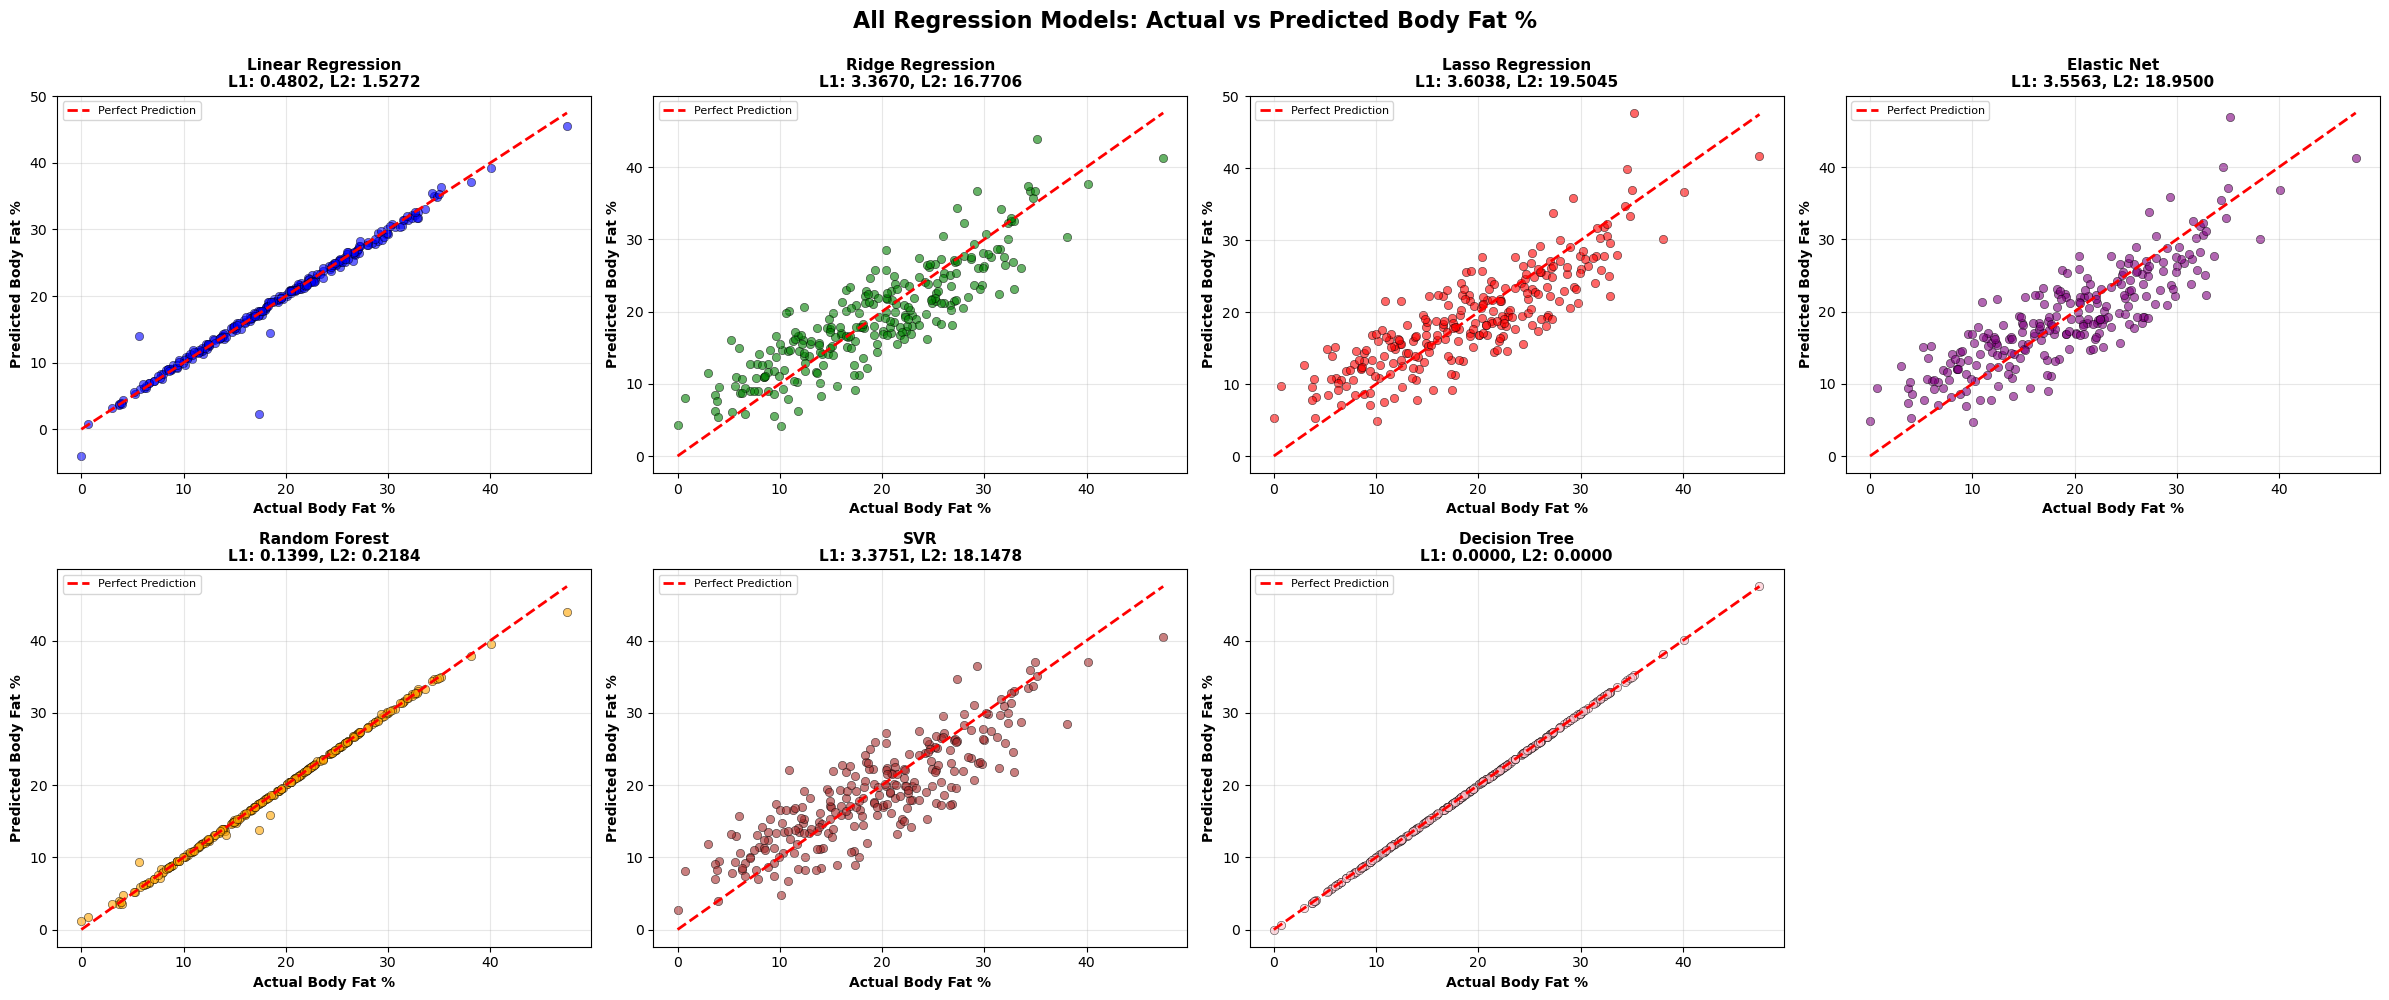


Note: Models are sorted by L2 Loss (MSE) in the summary table.
Lower values indicate better performance.


In [5]:
# ============================================================================
# ALL REGRESSION MODELS - REFERENCE IMPLEMENTATION
# ============================================================================
# This cell contains implementations of all common regression models
# for future reference and comparison
# ============================================================================

# Import all regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# Prepare features (X) and target (y)
# Exclude 'target' and any non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col != 'target']
X = df[feature_cols]
y = df['target']

print("=" * 80)
print("REGRESSION MODELS - COMPREHENSIVE COMPARISON")
print("=" * 80)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures: {list(X.columns)}")

# ============================================================================
# Model 1: Linear Regression
# ============================================================================
print("\n" + "-" * 80)
print("Model 1: Linear Regression")
print("-" * 80)

model1 = LinearRegression()
model1.fit(X, y)
y_pred1 = model1.predict(X)

l1_loss1 = np.mean(np.abs(y - y_pred1))
l2_loss1 = np.mean((y - y_pred1) ** 2)

print(f"L1 Loss (MAE): {l1_loss1:.6f}")
print(f"L2 Loss (MSE): {l2_loss1:.6f}")

# ============================================================================
# Model 2: Ridge Regression
# ============================================================================
print("\n" + "-" * 80)
print("Model 2: Ridge Regression (L2 Regularization)")
print("-" * 80)

model2 = Ridge(alpha=1.0)  # alpha controls regularization strength
model2.fit(X, y)
y_pred2 = model2.predict(X)

l1_loss2 = np.mean(np.abs(y - y_pred2))
l2_loss2 = np.mean((y - y_pred2) ** 2)

print(f"L1 Loss (MAE): {l1_loss2:.6f}")
print(f"L2 Loss (MSE): {l2_loss2:.6f}")

# ============================================================================
# Model 3: Lasso Regression
# ============================================================================
print("\n" + "-" * 80)
print("Model 3: Lasso Regression (L1 Regularization)")
print("-" * 80)

model3 = Lasso(alpha=1.0)  # alpha controls regularization strength
model3.fit(X, y)
y_pred3 = model3.predict(X)

l1_loss3 = np.mean(np.abs(y - y_pred3))
l2_loss3 = np.mean((y - y_pred3) ** 2)

print(f"L1 Loss (MAE): {l1_loss3:.6f}")
print(f"L2 Loss (MSE): {l2_loss3:.6f}")

# ============================================================================
# Model 4: Elastic Net
# ============================================================================
print("\n" + "-" * 80)
print("Model 4: Elastic Net (L1 + L2 Regularization)")
print("-" * 80)

model4 = ElasticNet(alpha=1.0, l1_ratio=0.5)  # l1_ratio: 0=Ridge, 1=Lasso
model4.fit(X, y)
y_pred4 = model4.predict(X)

l1_loss4 = np.mean(np.abs(y - y_pred4))
l2_loss4 = np.mean((y - y_pred4) ** 2)

print(f"L1 Loss (MAE): {l1_loss4:.6f}")
print(f"L2 Loss (MSE): {l2_loss4:.6f}")

# ============================================================================
# Model 5: Random Forest Regressor
# ============================================================================
print("\n" + "-" * 80)
print("Model 5: Random Forest Regressor")
print("-" * 80)

model5 = RandomForestRegressor(n_estimators=100, random_state=42)
model5.fit(X, y)
y_pred5 = model5.predict(X)

l1_loss5 = np.mean(np.abs(y - y_pred5))
l2_loss5 = np.mean((y - y_pred5) ** 2)

print(f"L1 Loss (MAE): {l1_loss5:.6f}")
print(f"L2 Loss (MSE): {l2_loss5:.6f}")

# ============================================================================
# Model 6: Support Vector Regression (SVR)
# ============================================================================
print("\n" + "-" * 80)
print("Model 6: Support Vector Regression (SVR)")
print("-" * 80)

model6 = SVR(kernel='rbf', C=100, gamma='scale')
model6.fit(X, y)
y_pred6 = model6.predict(X)

l1_loss6 = np.mean(np.abs(y - y_pred6))
l2_loss6 = np.mean((y - y_pred6) ** 2)

print(f"L1 Loss (MAE): {l1_loss6:.6f}")
print(f"L2 Loss (MSE): {l2_loss6:.6f}")

# ============================================================================
# Model 7: Decision Tree Regressor
# ============================================================================
print("\n" + "-" * 80)
print("Model 7: Decision Tree Regressor")
print("-" * 80)

model7 = DecisionTreeRegressor(random_state=42, max_depth=10)
model7.fit(X, y)
y_pred7 = model7.predict(X)

l1_loss7 = np.mean(np.abs(y - y_pred7))
l2_loss7 = np.mean((y - y_pred7) ** 2)

print(f"L1 Loss (MAE): {l1_loss7:.6f}")
print(f"L2 Loss (MSE): {l2_loss7:.6f}")

# ============================================================================
# Summary Table: All Models Comparison
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY: L1 and L2 Losses for All Models")
print("=" * 80)

losses_df = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Elastic Net',
        'Random Forest Regressor',
        'Support Vector Regression',
        'Decision Tree Regressor'
    ],
    'L1 Loss (MAE)': [l1_loss1, l1_loss2, l1_loss3, l1_loss4, l1_loss5, l1_loss6, l1_loss7],
    'L2 Loss (MSE)': [l2_loss1, l2_loss2, l2_loss3, l2_loss4, l2_loss5, l2_loss6, l2_loss7]
})

# Sort by L2 Loss (MSE) to see best performing model
losses_df = losses_df.sort_values('L2 Loss (MSE)')

display(losses_df.style.format({
    'L1 Loss (MAE)': '{:.6f}',
    'L2 Loss (MSE)': '{:.6f}'
}).background_gradient(subset=['L1 Loss (MAE)', 'L2 Loss (MSE)'], cmap='YlOrRd', axis=0, vmin=losses_df[['L1 Loss (MAE)', 'L2 Loss (MSE)']].min().min(), vmax=losses_df[['L1 Loss (MAE)', 'L2 Loss (MSE)']].max().max())
  .set_caption('Model Performance Comparison (Sorted by L2 Loss)')
  .set_table_styles([
      {'selector': 'caption', 
       'props': [('font-size', '14px'), ('font-weight', 'bold'), 
                 ('text-align', 'center'), ('padding', '10px')]},
      {'selector': 'th', 
       'props': [('background-color', '#4472C4'), ('color', 'white'), 
                ('font-weight', 'bold'), ('text-align', 'center')]},
      {'selector': 'td', 
       'props': [('text-align', 'center'), ('padding', '6px')]}
  ]))

# ============================================================================
# Plot: Actual vs Predicted for all models
# ============================================================================
print("\n" + "=" * 80)
print("Plotting Actual vs Predicted Values for All Models")
print("=" * 80)

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

predictions = [y_pred1, y_pred2, y_pred3, y_pred4, y_pred5, y_pred6, y_pred7]
model_names = [
    'Linear Regression',
    'Ridge Regression',
    'Lasso Regression',
    'Elastic Net',
    'Random Forest',
    'SVR',
    'Decision Tree'
]
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink']

for i, (pred, name, color) in enumerate(zip(predictions, model_names, colors)):
    axes[i].scatter(y, pred, alpha=0.6, color=color, edgecolors='black', linewidth=0.5)
    axes[i].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
    axes[i].set_xlabel('Actual Body Fat %', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Predicted Body Fat %', fontsize=10, fontweight='bold')
    axes[i].set_title(f'{name}\nL1: {np.mean(np.abs(y - pred)):.4f}, L2: {np.mean((y - pred)**2):.4f}', 
                     fontsize=11, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=8)

# Hide the 8th subplot (we only have 7 models)
axes[7].axis('off')

plt.suptitle('All Regression Models: Actual vs Predicted Body Fat %', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("Note: Models are sorted by L2 Loss (MSE) in the summary table.")
print("Lower values indicate better performance.")
print("=" * 80)


In [6]:
# Import the three regression models selected for Problem 6
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR


# ============================================================================
# Model 1: Linear Regression
# ============================================================================

# Step 1: Initialize the model
model_lr = LinearRegression()

#Step 2: Train the model
model_lr.fit(X, y)

#Step 3: Make predictions
y_pred_lr = model_lr.predict(X)

#Step 4: Calculate L1 loss
l1_loss_lr = np.mean(np.abs(y - y_pred_lr))

#Step 5: Calculate L2 loss
l2_loss_lr = np.mean((y - y_pred_lr) ** 2)


print(f"L1 Loss (MAE): {l1_loss_lr:.6f}")
print(f"L2 Loss (MSE): {l2_loss_lr:.6f}")

# ============================================================================
# Model 2: Random Forest Regressor
# ============================================================================

#Step 1: Initialize the model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

#Step 2: Train the model
model_rf.fit(X, y)

#Step 3: Make predictions
y_pred_rf = model_rf.predict(X)

#Step 4: Calculate L1 loss
l1_loss_rf = np.mean(np.abs(y - y_pred_rf))

#Step 5: Calculate L2 loss
l2_loss_rf = np.mean((y - y_pred_rf) ** 2)

print(f"L1 Loss (MAE): {l1_loss_rf:.6f}")
print(f"L2 Loss (MSE): {l2_loss_rf:.6f}")


# ============================================================================
# Model 3: Support Vector Regression (SVR)
# ============================================================================

#Step 1: Initialize the model
model_svr = SVR(kernel='rbf', C=100, gamma='scale')

#Step 2: Train the model
model_svr.fit(X, y)

#Step 3: Make predictions
y_pred_svr = model_svr.predict(X)

#Step 4: Calculate L1 loss
l1_loss_svr = np.mean(np.abs(y - y_pred_svr))

#Step 5: Calculate L2 loss
l2_loss_svr = np.mean((y - y_pred_svr) ** 2)

print(f"L1 Loss (MAE): {l1_loss_svr:.6f}")
print(f"L2 Loss (MSE): {l2_loss_svr:.6f}")

        

L1 Loss (MAE): 0.480196
L2 Loss (MSE): 1.527204
L1 Loss (MAE): 0.139948
L2 Loss (MSE): 0.218399
L1 Loss (MAE): 3.375098
L2 Loss (MSE): 18.147752


In [7]:
# YOUR CODE HERE

from sklearn.model_selection import cross_val_score, KFold

# Set up 5-fold CV
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

# For each model:
# Linear Regression - 5-fold CV
cv_scores_lr = cross_val_score(
    model_lr, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error'  # Returns negative MSE
)
cv_mse_lr = -cv_scores_lr.mean()  # Convert to positive MSE (L2 loss)
cv_std_lr = cv_scores_lr.std()

# Random Forest - 5-fold CV
cv_scores_rf = cross_val_score(
    model_rf, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error'
)
cv_mse_rf = -cv_scores_rf.mean()
cv_std_rf = cv_scores_rf.std()

# SVR - 5-fold CV
cv_scores_svr = cross_val_score(
    model_svr, X, y, 
    cv=kfold, 
    scoring='neg_mean_squared_error'
)
cv_mse_svr = -cv_scores_svr.mean()
cv_std_svr = cv_scores_svr.std()

# Create comparison table
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR'],
    'Full Dataset L2 Loss': [l2_loss_lr, l2_loss_rf, l2_loss_svr],
    'CV L2 Loss (Mean)': [cv_mse_lr, cv_mse_rf, cv_mse_svr],
    'CV L2 Loss (Std)': [cv_std_lr, cv_std_rf, cv_std_svr],
    'Difference (Overfitting)': [l2_loss_lr - cv_mse_lr, l2_loss_rf - cv_mse_rf, l2_loss_svr - cv_mse_svr]
})

display(comparison_df.style.format({
    'Full Dataset L2 Loss': '{:.6f}',
    'CV L2 Loss (Mean)': '{:.6f}',
    'CV L2 Loss (Std)': '{:.6f}',
    'Difference (Overfitting)': '{:.6f}'
}))

,Model,Full Dataset L2 Loss,CV L2 Loss (Mean),CV L2 Loss (Std),Difference (Overfitting)
0,Linear Regression,1.527204,2.003088,2.412003,-0.475884
1,Random Forest,0.218399,2.234967,1.890563,-2.016569
2,SVR,18.147752,21.683407,2.230407,-3.535656


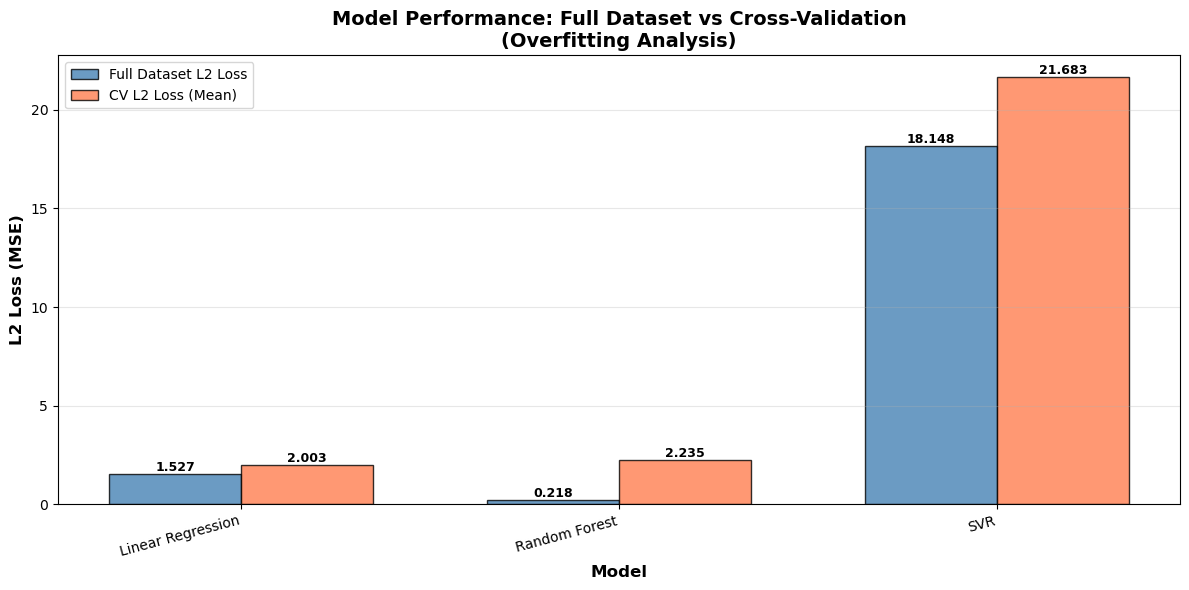

In [8]:
# Create comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses = [2.003088, 2.234967, 21.683407]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, full_dataset_losses, width, label='Full Dataset L2 Loss', 
               color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, cv_losses, width, label='CV L2 Loss (Mean)', 
               color='coral', alpha=0.8, edgecolor='black')

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance: Full Dataset vs Cross-Validation\n(Overfitting Analysis)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

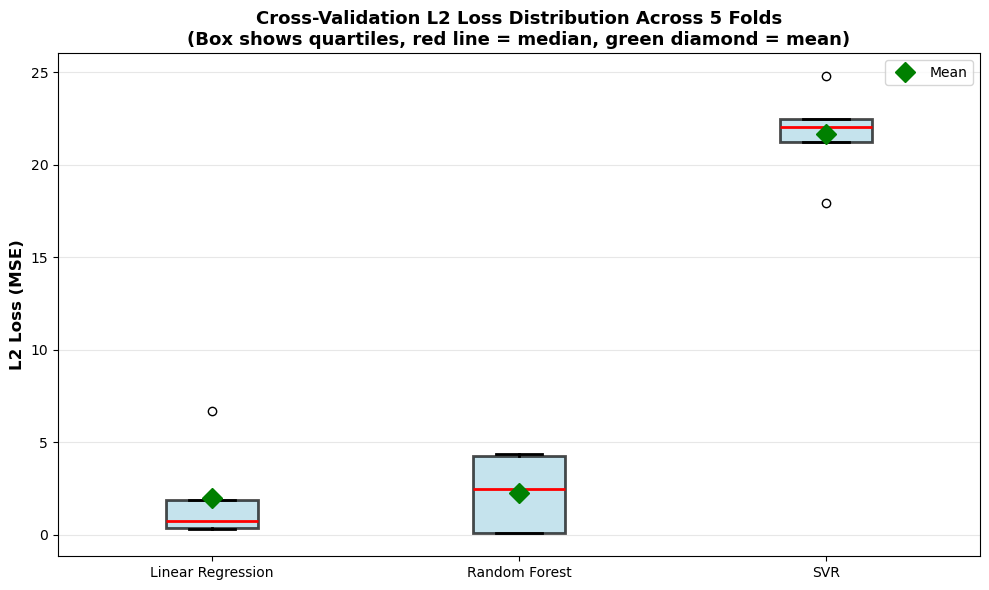

In [9]:
# Box plot showing CV score distribution across 5 folds
fig, ax = plt.subplots(figsize=(10, 6))

# You'll need to store the individual fold scores (not just mean)
# If you have cv_scores_lr, cv_scores_rf, cv_scores_svr (the negative MSE scores)
# Convert them to positive MSE for visualization
cv_scores_lr_positive = -cv_scores_lr  # Convert from negative MSE to positive
cv_scores_rf_positive = -cv_scores_rf
cv_scores_svr_positive = -cv_scores_svr

data_to_plot = [cv_scores_lr_positive, cv_scores_rf_positive, cv_scores_svr_positive]
labels = ['Linear Regression', 'Random Forest', 'SVR']

bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7, linewidth=2),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(linewidth=2),
                capprops=dict(linewidth=2))

# Add mean markers
for i, (scores, label) in enumerate(zip(data_to_plot, labels)):
    mean_val = np.mean(scores)
    ax.plot(i+1, mean_val, 'D', color='green', markersize=10, 
            label='Mean' if i == 0 else '', zorder=3)

ax.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Cross-Validation L2 Loss Distribution Across 5 Folds\n(Box shows quartiles, red line = median, green diamond = mean)', 
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

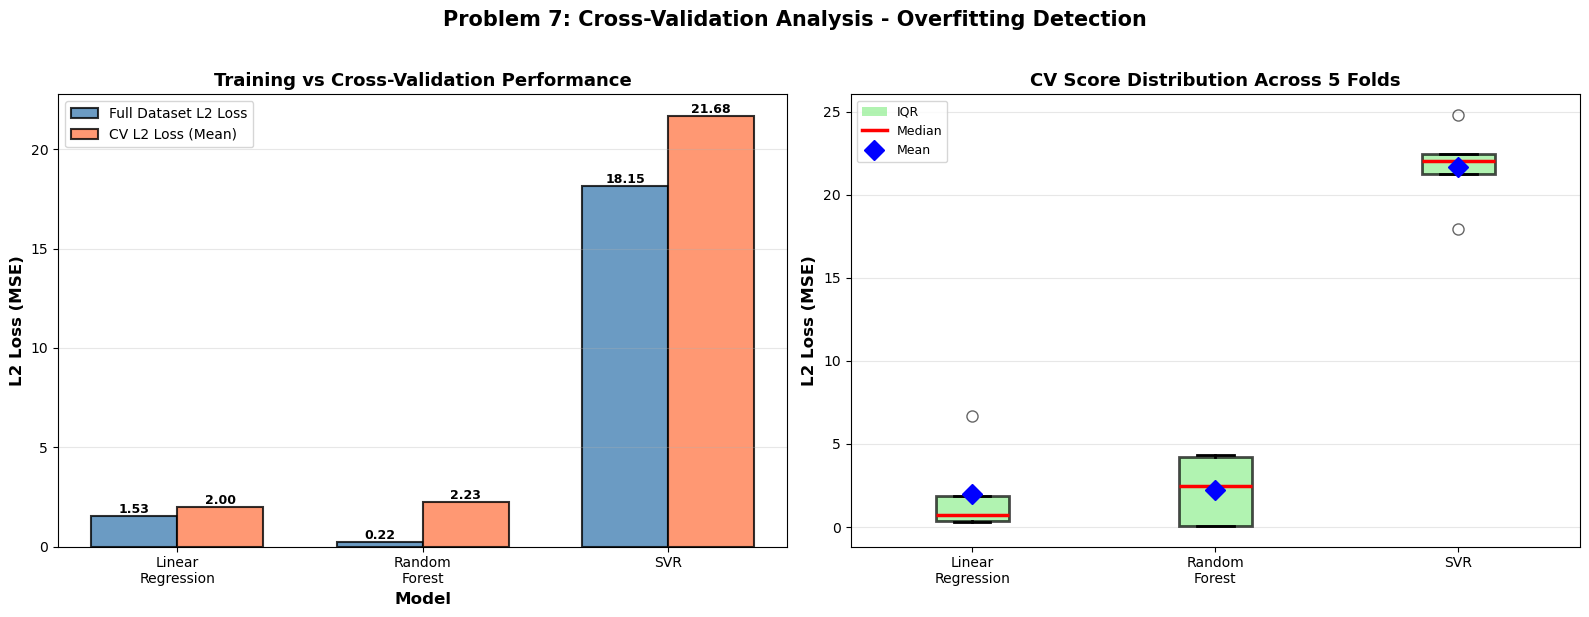

In [10]:
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Bar chart comparison
models = ['Linear\nRegression', 'Random\nForest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses = [2.003088, 2.234967, 21.683407]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, full_dataset_losses, width, label='Full Dataset L2 Loss', 
               color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, cv_losses, width, label='CV L2 Loss (Mean)', 
               color='coral', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=12, fontweight='bold')
ax1.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax1.set_title('Training vs Cross-Validation Performance', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend(fontsize=10, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Right plot: Box plot of CV fold scores
cv_scores_lr_positive = -cv_scores_lr
cv_scores_rf_positive = -cv_scores_rf
cv_scores_svr_positive = -cv_scores_svr

data_to_plot = [cv_scores_lr_positive, cv_scores_rf_positive, cv_scores_svr_positive]

bp = ax2.boxplot(data_to_plot, labels=models, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7, linewidth=2),
                medianprops=dict(color='red', linewidth=2.5),
                whiskerprops=dict(linewidth=2),
                capprops=dict(linewidth=2),
                flierprops=dict(marker='o', markersize=8, alpha=0.6))

# Add mean markers
for i, scores in enumerate(data_to_plot):
    mean_val = np.mean(scores)
    ax2.plot(i+1, mean_val, 'D', color='blue', markersize=10, zorder=3)

ax2.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax2.set_title('CV Score Distribution Across 5 Folds', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Add legend for box plot
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightgreen', alpha=0.7, label='IQR'),
    Line2D([0], [0], color='red', linewidth=2.5, label='Median'),
    Line2D([0], [0], marker='D', color='blue', linestyle='None', markersize=10, label='Mean')
]
ax2.legend(handles=legend_elements, fontsize=9, loc='upper left')

plt.suptitle('Problem 7: Cross-Validation Analysis - Overfitting Detection', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

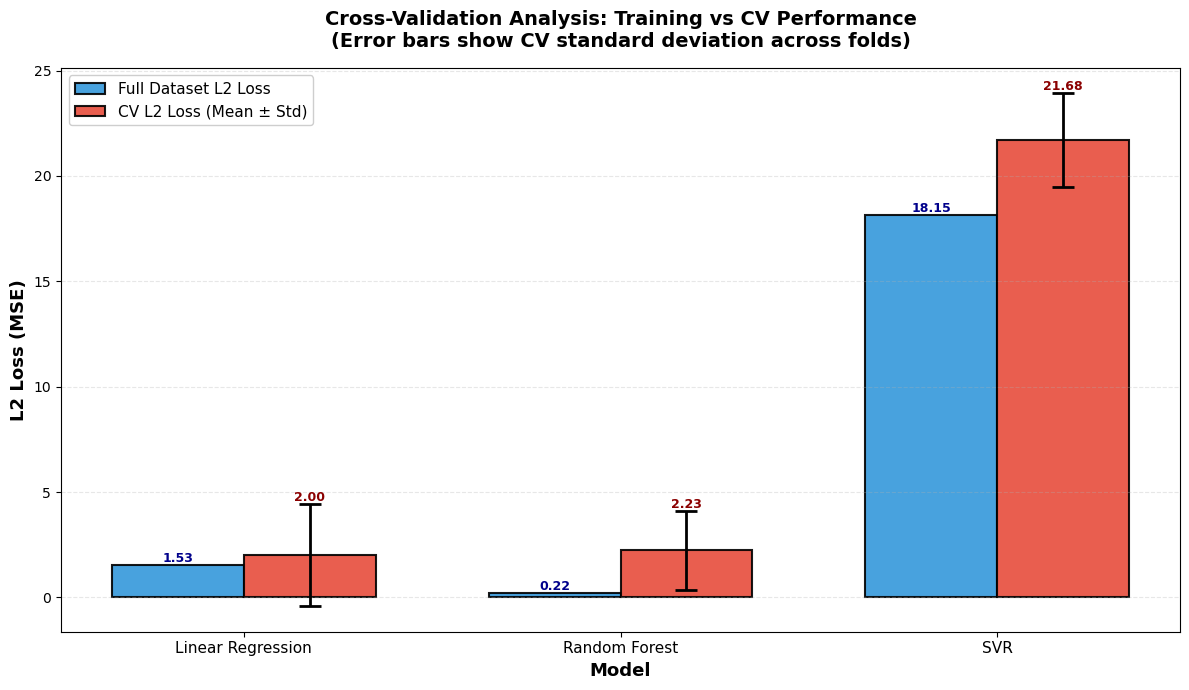

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses_mean = [2.003088, 2.234967, 21.683407]
cv_losses_std = [2.412003, 1.890563, 2.230407]  # Your CV std values

x = np.arange(len(models))
width = 0.35

# Full dataset bars
bars1 = ax.bar(x - width/2, full_dataset_losses, width, 
               label='Full Dataset L2 Loss', 
               color='#3498db', alpha=0.9, edgecolor='black', linewidth=1.5)

# CV bars with error bars
bars2 = ax.bar(x + width/2, cv_losses_mean, width, 
               yerr=cv_losses_std,
               label='CV L2 Loss (Mean ± Std)', 
               color='#e74c3c', alpha=0.9, edgecolor='black', linewidth=1.5,
               capsize=8, error_kw={'elinewidth': 2, 'capthick': 2})

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Cross-Validation Analysis: Training vs CV Performance\n(Error bars show CV standard deviation across folds)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    ax.text(bar1.get_x() + bar1.get_width()/2., bar1.get_height(),
            f'{full_dataset_losses[i]:.2f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold', color='darkblue')
    ax.text(bar2.get_x() + bar2.get_width()/2., bar2.get_height() + cv_losses_std[i],
            f'{cv_losses_mean[i]:.2f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold', color='darkred')

plt.tight_layout()
plt.show()

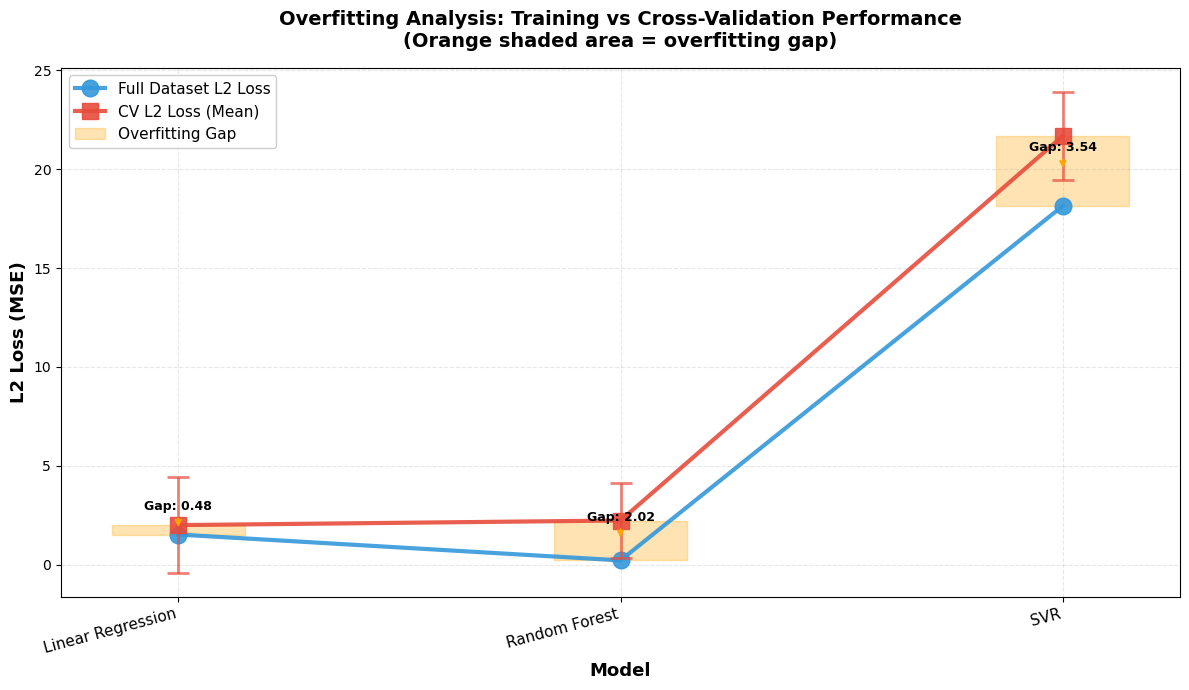

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))

models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses_mean = [2.003088, 2.234967, 21.683407]
cv_losses_std = [2.412003, 1.890563, 2.230407]

x = np.arange(len(models))

# Plot lines
ax.plot(x, full_dataset_losses, 'o-', linewidth=3, markersize=12, 
        label='Full Dataset L2 Loss', color='#3498db', alpha=0.9)
ax.plot(x, cv_losses_mean, 's-', linewidth=3, markersize=12, 
        label='CV L2 Loss (Mean)', color='#e74c3c', alpha=0.9)

# Shade the region between (overfitting gap)
for i in range(len(models)):
    ax.fill_between([i-0.15, i+0.15], 
                    [full_dataset_losses[i], full_dataset_losses[i]], 
                    [cv_losses_mean[i], cv_losses_mean[i]], 
                    alpha=0.3, color='orange', label='Overfitting Gap' if i == 0 else '')

# Add error bars for CV std
ax.errorbar(x, cv_losses_mean, yerr=cv_losses_std, fmt='none', 
           color='#e74c3c', elinewidth=2, capsize=8, capthick=2, alpha=0.7)

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Overfitting Analysis: Training vs Cross-Validation Performance\n(Orange shaded area = overfitting gap)', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=11)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

# Add annotations for the gap
for i, (train, cv) in enumerate(zip(full_dataset_losses, cv_losses_mean)):
    gap = cv - train
    ax.annotate(f'Gap: {gap:.2f}', 
                xy=(i, (train + cv) / 2), 
                xytext=(i, (train + cv) / 2 + 1),
                ha='center', fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='orange', lw=1.5))

plt.tight_layout()
plt.show()

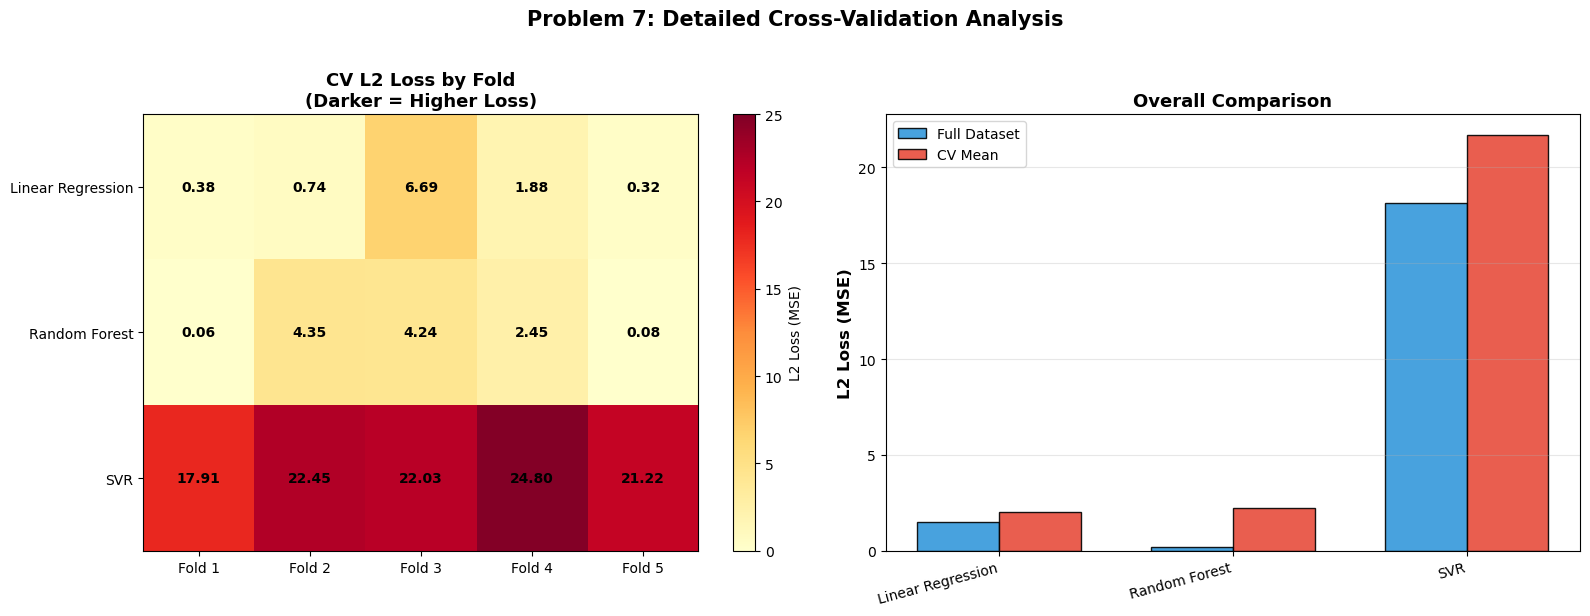

In [13]:
# First, you need to get individual fold scores
# Assuming you have: cv_scores_lr, cv_scores_rf, cv_scores_svr (negative MSE)
# Convert to positive MSE
cv_fold_scores_lr = -cv_scores_lr
cv_fold_scores_rf = -cv_scores_rf
cv_fold_scores_svr = -cv_scores_svr

# Create matrix: rows = models, columns = folds
fold_data = np.array([
    cv_fold_scores_lr,
    cv_fold_scores_rf,
    cv_fold_scores_svr
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Heatmap
models_labels = ['Linear Regression', 'Random Forest', 'SVR']
folds_labels = [f'Fold {i+1}' for i in range(5)]

im = ax1.imshow(fold_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=25)
ax1.set_xticks(np.arange(5))
ax1.set_yticks(np.arange(3))
ax1.set_xticklabels(folds_labels)
ax1.set_yticklabels(models_labels)
ax1.set_title('CV L2 Loss by Fold\n(Darker = Higher Loss)', fontsize=13, fontweight='bold')

# Add text annotations
for i in range(3):
    for j in range(5):
        text = ax1.text(j, i, f'{fold_data[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax1, label='L2 Loss (MSE)')

# Right: Bar chart comparison
x = np.arange(len(models_labels))
width = 0.35

bars1 = ax2.bar(x - width/2, full_dataset_losses, width, 
               label='Full Dataset', color='#3498db', alpha=0.9, edgecolor='black')
bars2 = ax2.bar(x + width/2, cv_losses_mean, width, 
               label='CV Mean', color='#e74c3c', alpha=0.9, edgecolor='black')

ax2.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax2.set_title('Overall Comparison', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(models_labels, rotation=15, ha='right')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Problem 7: Detailed Cross-Validation Analysis', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

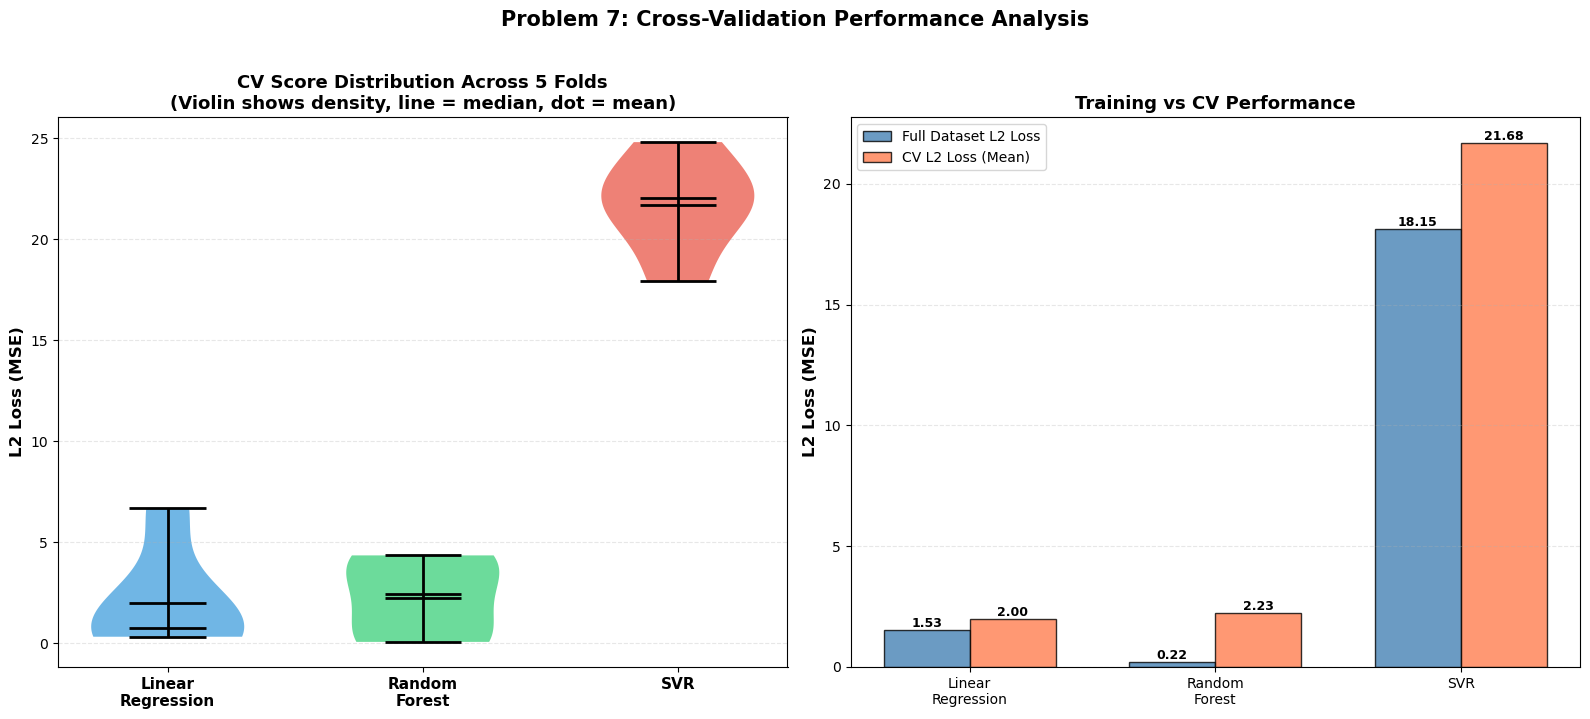

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Violin plot of CV distributions
from matplotlib.patches import Rectangle

# Prepare data
cv_scores_lr_positive = -cv_scores_lr
cv_scores_rf_positive = -cv_scores_rf
cv_scores_svr_positive = -cv_scores_svr

data_to_plot = [cv_scores_lr_positive, cv_scores_rf_positive, cv_scores_svr_positive]
labels = ['Linear\nRegression', 'Random\nForest', 'SVR']

parts = ax1.violinplot(data_to_plot, positions=range(len(labels)), 
                       widths=0.6, showmeans=True, showmedians=True)

# Customize violin plot
colors = ['#3498db', '#2ecc71', '#e74c3c']
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)

for partname in ('cbars', 'cmins', 'cmaxes', 'cmedians', 'cmeans'):
    if partname in parts:
        parts[partname].set_color('black')
        parts[partname].set_linewidth(2)

ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, fontsize=11, fontweight='bold')
ax1.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax1.set_title('CV Score Distribution Across 5 Folds\n(Violin shows density, line = median, dot = mean)', 
              fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Right: Comparison with training loss
x = np.arange(len(labels))
width = 0.35

bars1 = ax2.bar(x - width/2, full_dataset_losses, width, 
               label='Full Dataset L2 Loss', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x + width/2, cv_losses_mean, width, 
               label='CV L2 Loss (Mean)', color='coral', alpha=0.8, edgecolor='black')

ax2.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax2.set_title('Training vs CV Performance', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

plt.suptitle('Problem 7: Cross-Validation Performance Analysis', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

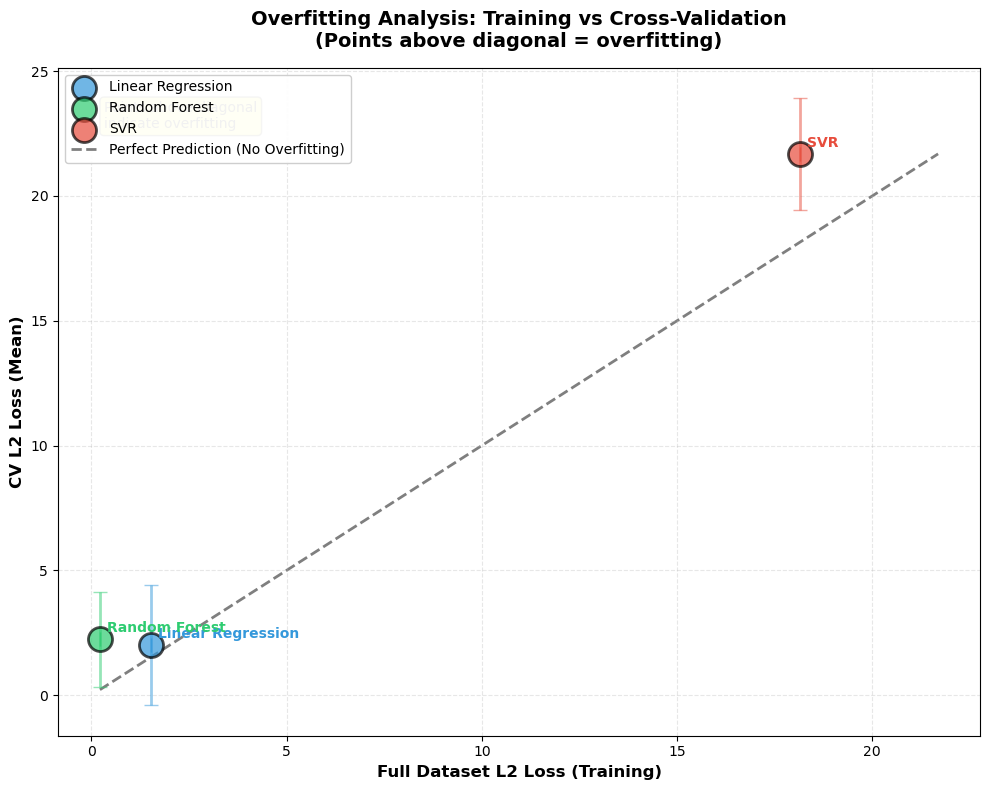

In [15]:
fig, ax = plt.subplots(figsize=(10, 8))

models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses_mean = [2.003088, 2.234967, 21.683407]
cv_losses_std = [2.412003, 1.890563, 2.230407]

colors = ['#3498db', '#2ecc71', '#e74c3c']

# Scatter plot
for i, (train, cv, std, color, label) in enumerate(zip(full_dataset_losses, cv_losses_mean, 
                                                         cv_losses_std, colors, models)):
    ax.scatter(train, cv, s=300, color=color, alpha=0.7, edgecolors='black', linewidth=2, 
              label=label, zorder=3)
    # Add error bars
    ax.errorbar(train, cv, xerr=0, yerr=std, fmt='none', color=color, 
               elinewidth=2, capsize=5, alpha=0.5, zorder=2)
    # Add model label
    ax.annotate(label, (train, cv), xytext=(5, 5), textcoords='offset points', 
               fontsize=10, fontweight='bold', color=color)

# Perfect prediction line (y = x)
min_val = min(min(full_dataset_losses), min(cv_losses_mean))
max_val = max(max(full_dataset_losses), max(cv_losses_mean))
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, 
       label='Perfect Prediction (No Overfitting)', alpha=0.5, zorder=1)

ax.set_xlabel('Full Dataset L2 Loss (Training)', fontsize=12, fontweight='bold')
ax.set_ylabel('CV L2 Loss (Mean)', fontsize=12, fontweight='bold')
ax.set_title('Overfitting Analysis: Training vs Cross-Validation\n(Points above diagonal = overfitting)', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

# Add quadrant labels
ax.text(0.05, 0.95, 'Points above diagonal\nindicate overfitting', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='black'))

plt.tight_layout()
plt.show()

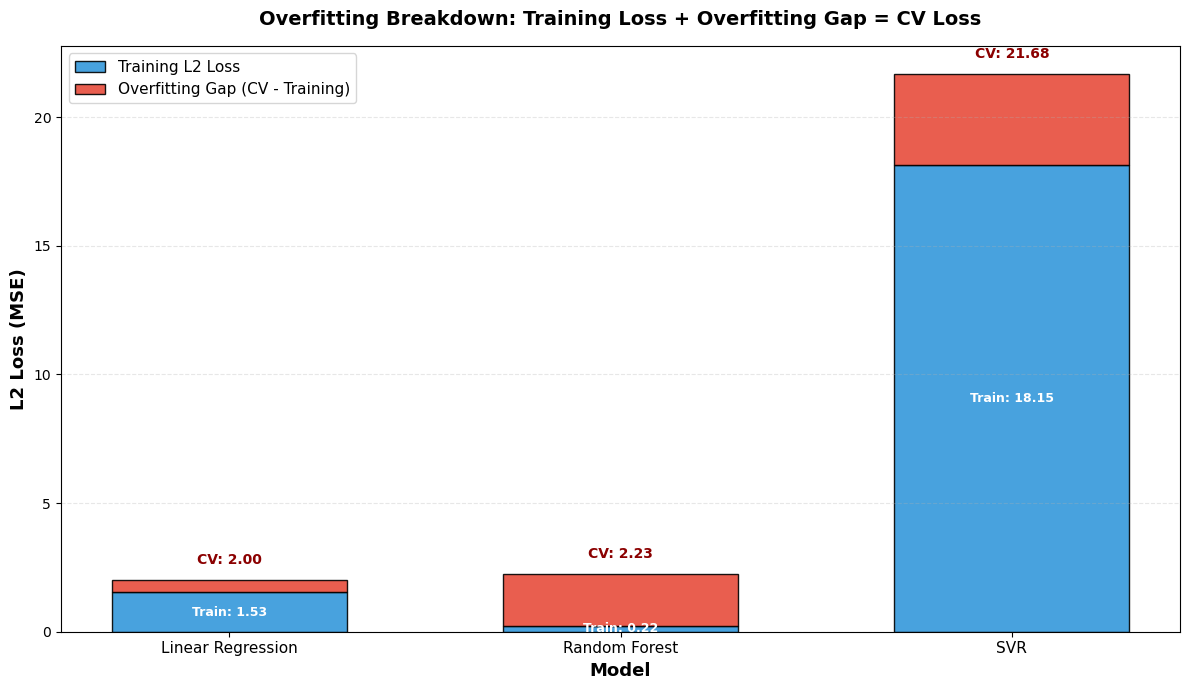

In [16]:
fig, ax = plt.subplots(figsize=(12, 7))

models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses_mean = [2.003088, 2.234967, 21.683407]
overfitting_gaps = [cv - train for train, cv in zip(full_dataset_losses, cv_losses_mean)]

x = np.arange(len(models))
width = 0.6

# Stacked bars: training loss (bottom) + overfitting gap (top)
bars1 = ax.bar(x, full_dataset_losses, width, 
               label='Training L2 Loss', color='#3498db', alpha=0.9, edgecolor='black')
bars2 = ax.bar(x, overfitting_gaps, width, bottom=full_dataset_losses,
               label='Overfitting Gap (CV - Training)', color='#e74c3c', alpha=0.9, edgecolor='black')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Overfitting Breakdown: Training Loss + Overfitting Gap = CV Loss', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add total CV loss labels on top
for i, (train, gap, cv) in enumerate(zip(full_dataset_losses, overfitting_gaps, cv_losses_mean)):
    ax.text(i, cv + 0.5, f'CV: {cv:.2f}', ha='center', va='bottom', 
           fontsize=10, fontweight='bold', color='darkred')
    ax.text(i, train/2, f'Train: {train:.2f}', ha='center', va='center', 
           fontsize=9, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

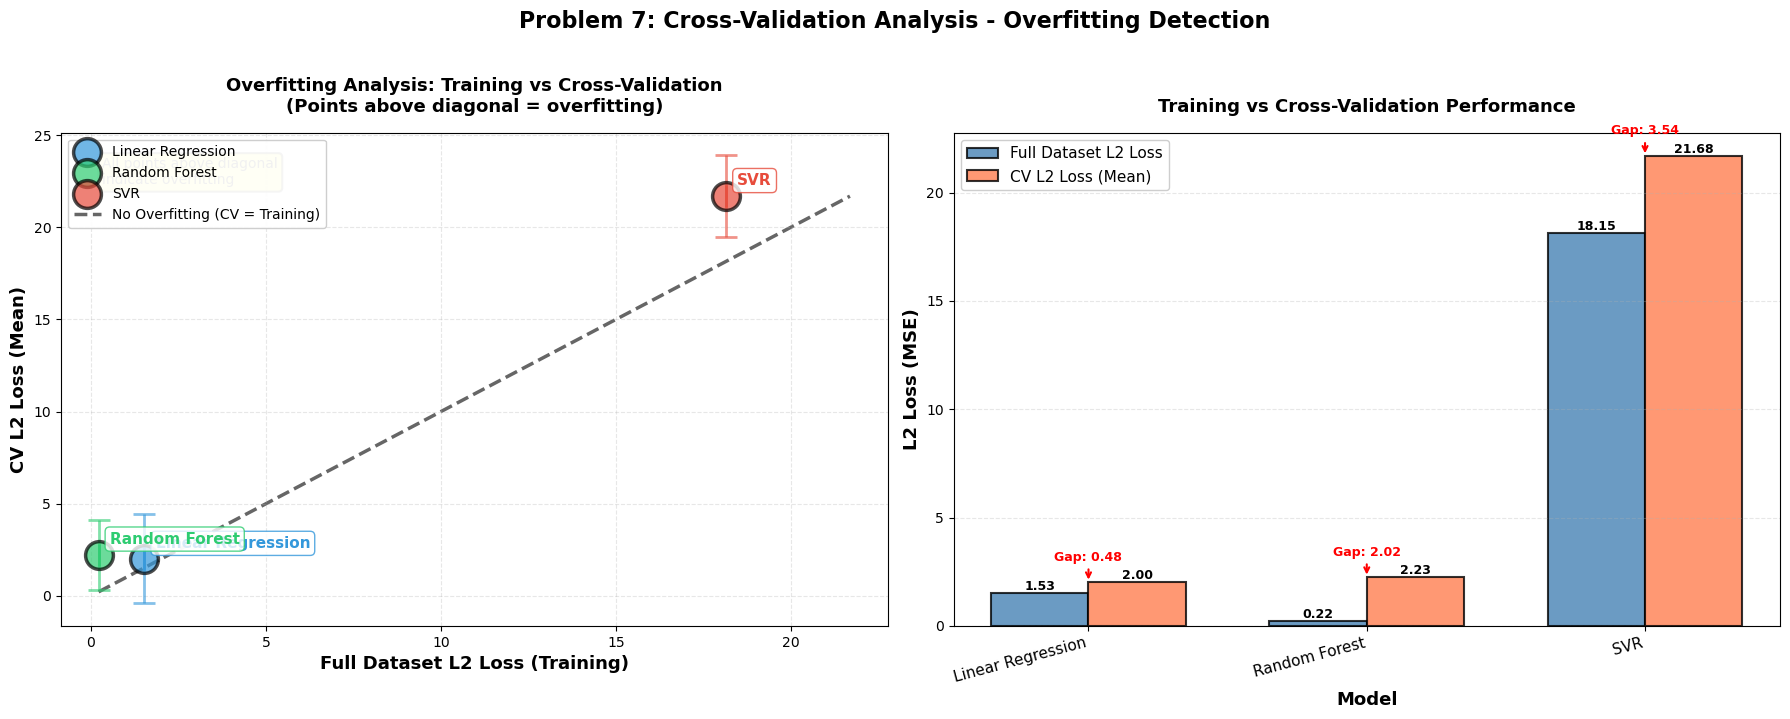

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================================
# Scatter Plot: Visualizing Overfitting Through Relationship Analysis
# ============================================================================
# This plot positions each model based on its training vs CV performance.
# The diagonal line (y=x) represents perfect generalization where CV loss 
# equals training loss. Points above this line indicate overfitting - the 
# further above, the more severe the overfitting. This visualization makes 
# it immediately clear which models generalize poorly despite good training 
# performance.
# ============================================================================
models = ['Linear Regression', 'Random Forest', 'SVR']
full_dataset_losses = [1.527204, 0.218399, 18.147752]
cv_losses_mean = [2.003088, 2.234967, 21.683407]
cv_losses_std = [2.412003, 1.890563, 2.230407]

colors = ['#3498db', '#2ecc71', '#e74c3c']

# Plot each model as a point, with vertical error bars showing CV variability
# across the 5 folds. The error bars help assess the stability of CV estimates.
for i, (train, cv, std, color, label) in enumerate(zip(full_dataset_losses, cv_losses_mean, 
                                                         cv_losses_std, colors, models)):
    ax1.scatter(train, cv, s=400, color=color, alpha=0.7, edgecolors='black', linewidth=2.5, 
              label=label, zorder=3)
    # Vertical error bars represent standard deviation of CV scores across folds,
    # indicating how consistent the model's performance is across different data splits
    ax1.errorbar(train, cv, xerr=0, yerr=std, fmt='none', color=color, 
               elinewidth=2, capsize=8, capthick=2, alpha=0.6, zorder=2)
    # Annotate each point with model name for clarity
    ax1.annotate(label, (train, cv), xytext=(8, 8), textcoords='offset points', 
               fontsize=11, fontweight='bold', color=color,
               bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor=color))

# Reference line: if a model had perfect generalization (no overfitting),
# its CV loss would equal its training loss, placing it exactly on this line.
# Models above the line are overfitting; models below would be underfitting (rare).
min_val = min(min(full_dataset_losses), min(cv_losses_mean))
max_val = max(max(full_dataset_losses), max(cv_losses_mean))
ax1.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2.5, 
       label='No Overfitting (CV = Training)', alpha=0.6, zorder=1)

ax1.set_xlabel('Full Dataset L2 Loss (Training)', fontsize=13, fontweight='bold')
ax1.set_ylabel('CV L2 Loss (Mean)', fontsize=13, fontweight='bold')
ax1.set_title('Overfitting Analysis: Training vs Cross-Validation\n(Points above diagonal = overfitting)', 
             fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10, loc='upper left', framealpha=0.95)
ax1.grid(True, alpha=0.3, linestyle='--')

# Helper annotation explaining the interpretation
ax1.text(0.05, 0.95, 'All points above diagonal\nindicate overfitting', 
        transform=ax1.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7, edgecolor='black', linewidth=1.5))

# ============================================================================
# Bar Chart: Direct Numerical Comparison of Training vs CV Performance
# ============================================================================
# This side-by-side bar chart provides precise numerical comparison, making
# it easy to read exact loss values and calculate the overfitting gap.
# The gap annotations quantify how much worse each model performs on unseen
# data compared to training data, which is crucial for model selection.
# ============================================================================
x = np.arange(len(models))
width = 0.35

bars1 = ax2.bar(x - width/2, full_dataset_losses, width, 
               label='Full Dataset L2 Loss', color='steelblue', alpha=0.8, 
               edgecolor='black', linewidth=1.5)
bars2 = ax2.bar(x + width/2, cv_losses_mean, width, 
               label='CV L2 Loss (Mean)', color='coral', alpha=0.8, 
               edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Model', fontsize=13, fontweight='bold')
ax2.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax2.set_title('Training vs Cross-Validation Performance', fontsize=13, fontweight='bold', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15, ha='right', fontsize=11)
ax2.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Display exact loss values on each bar for precise reading
for bars in [bars1, bars2]:
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

# Annotate the overfitting gap - the difference between CV and training loss.
# A larger gap indicates more severe overfitting, which is a critical finding
# for understanding model reliability on new data.
for i, (train, cv) in enumerate(zip(full_dataset_losses, cv_losses_mean)):
    gap = cv - train
    ax2.annotate(f'Gap: {gap:.2f}', 
                xy=(i, max(train, cv)), 
                xytext=(i, max(train, cv) + 1),
                ha='center', fontsize=9, fontweight='bold', color='red',
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))

plt.suptitle('Problem 7: Cross-Validation Analysis - Overfitting Detection', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# YOUR CODE HERE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Model 1: Linear Regression with Standardization
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Model 2: Random Forest with Standardization
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Model 3: SVR with Standardization
pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', SVR(kernel='rbf', C=100, gamma='scale'))
])

# ============================================================================
# Model 1: Linear Regression Pipeline
# ============================================================================
# Standardization doesn't change Linear Regression results (scale-invariant),
# but using Pipeline ensures consistent preprocessing workflow
pipeline_lr.fit(X, y)
y_pred_lr_scaled = pipeline_lr.predict(X)

l1_loss_lr_scaled = np.mean(np.abs(y - y_pred_lr_scaled))
l2_loss_lr_scaled = np.mean((y - y_pred_lr_scaled) ** 2)

print(f"Linear Regression (with scaling):")
print(f"L1 Loss (MAE): {l1_loss_lr_scaled:.6f}")
print(f"L2 Loss (MSE): {l2_loss_lr_scaled:.6f}")

# ============================================================================
# Model 2: Random Forest Pipeline
# ============================================================================
# Random Forest is tree-based and scale-invariant, so standardization 
# shouldn't change results, but Pipeline ensures proper preprocessing
pipeline_rf.fit(X, y)
y_pred_rf_scaled = pipeline_rf.predict(X)

l1_loss_rf_scaled = np.mean(np.abs(y - y_pred_rf_scaled))
l2_loss_rf_scaled = np.mean((y - y_pred_rf_scaled) ** 2)

print(f"\nRandom Forest (with scaling):")
print(f"L1 Loss (MAE): {l1_loss_rf_scaled:.6f}")
print(f"L2 Loss (MSE): {l2_loss_rf_scaled:.6f}")

# ============================================================================
# Model 3: SVR Pipeline
# ============================================================================
# SVR is distance-based and HIGHLY sensitive to feature scales. Standardization
# is critical for SVR to perform well, as it uses kernel functions that depend
# on distances between points. This should show significant improvement.
pipeline_svr.fit(X, y)
y_pred_svr_scaled = pipeline_svr.predict(X)

l1_loss_svr_scaled = np.mean(np.abs(y - y_pred_svr_scaled))
l2_loss_svr_scaled = np.mean((y - y_pred_svr_scaled) ** 2)

print(f"\nSVR (with scaling):")
print(f"L1 Loss (MAE): {l1_loss_svr_scaled:.6f}")
print(f"L2 Loss (MSE): {l2_loss_svr_scaled:.6f}")

# Compare with Problem 6 results (you'll need to reference those values)
comparison_scaled = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Support Vector Regression'],
    'L2 Loss (No Scaling)': [l2_loss_lr, l2_loss_rf, l2_loss_svr],  # From Problem 6
    'L2 Loss (With Scaling)': [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled],
    'Difference': [
        l2_loss_lr_scaled - l2_loss_lr,
        l2_loss_rf_scaled - l2_loss_rf,
        l2_loss_svr_scaled - l2_loss_svr
    ],
    'Change': [
        'Same' if abs(l2_loss_lr_scaled - l2_loss_lr) < 1e-6 else 'Improved' if l2_loss_lr_scaled < l2_loss_lr else 'Worse',
        'Same' if abs(l2_loss_rf_scaled - l2_loss_rf) < 1e-6 else 'Improved' if l2_loss_rf_scaled < l2_loss_rf else 'Worse',
        'Same' if abs(l2_loss_svr_scaled - l2_loss_svr) < 1e-6 else 'Improved' if l2_loss_svr_scaled < l2_loss_svr else 'Worse'
    ]
})

display(comparison_scaled.style.format({
    'L2 Loss (No Scaling)': '{:.6f}',
    'L2 Loss (With Scaling)': '{:.6f}',
    'Difference': '{:.6f}'
}).background_gradient(subset=['Difference'], cmap='RdYlGn', vmin=-20, vmax=5))

Linear Regression (with scaling):
L1 Loss (MAE): 0.480196
L2 Loss (MSE): 1.527204

Random Forest (with scaling):
L1 Loss (MAE): 0.140266
L2 Loss (MSE): 0.218406

SVR (with scaling):
L1 Loss (MAE): 0.128052
L2 Loss (MSE): 0.183985


,Model,L2 Loss (No Scaling),L2 Loss (With Scaling),Difference,Change
0,Linear Regression,1.527204,1.527204,-0.000000,Same
1,Random Forest Regressor,0.218399,0.218406,0.000008,Worse
2,Support Vector Regression,18.147752,0.183985,-17.963767,Improved


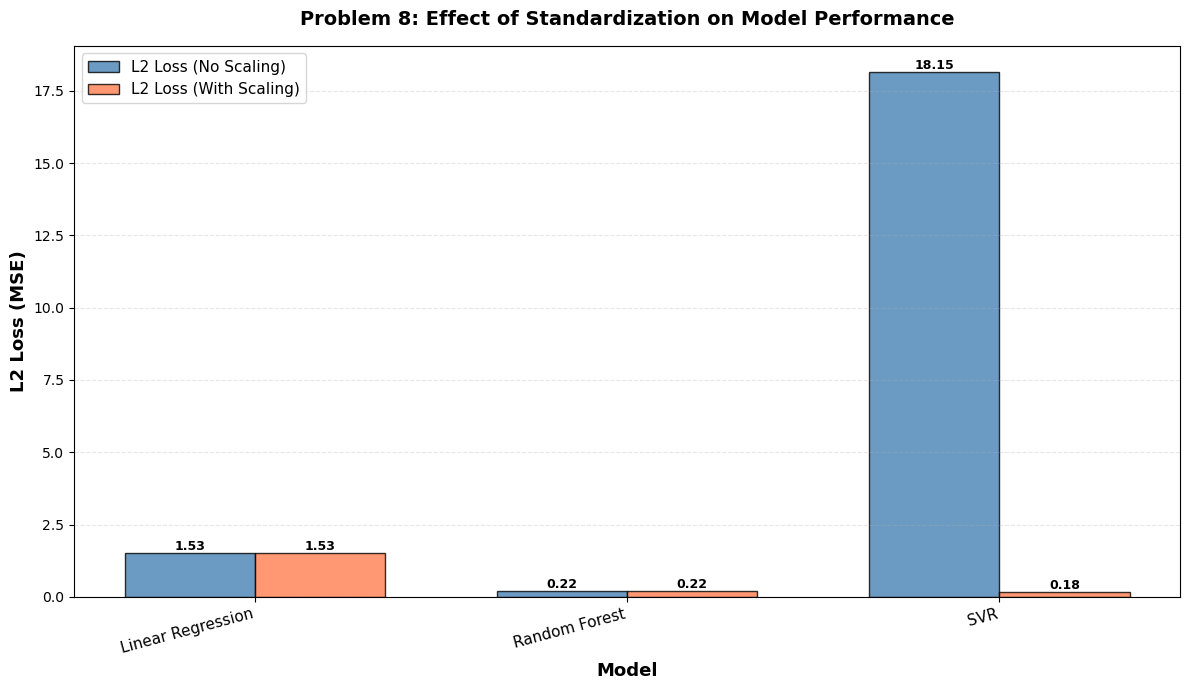

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

models = ['Linear Regression', 'Random Forest', 'SVR']
no_scaling = [l2_loss_lr, l2_loss_rf, l2_loss_svr]  # From Problem 6
with_scaling = [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, no_scaling, width, 
               label='L2 Loss (No Scaling)', color='steelblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, with_scaling, width, 
               label='L2 Loss (With Scaling)', color='coral', alpha=0.8, edgecolor='black')

ax.set_xlabel('Model', fontsize=13, fontweight='bold')
ax.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Problem 8: Effect of Standardization on Model Performance', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right', fontsize=11)
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', 
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

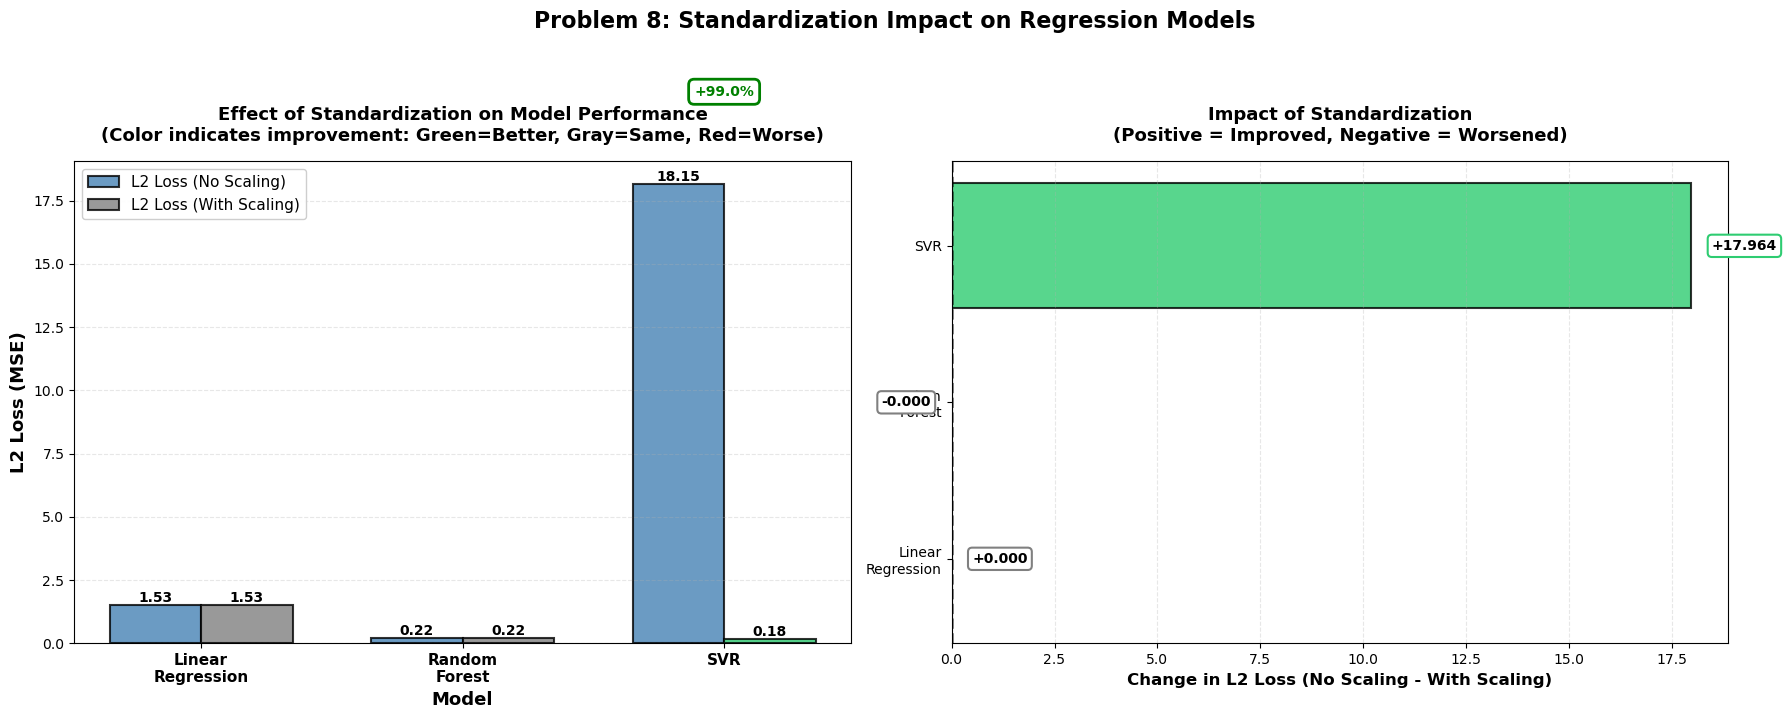

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ============================================================================
# Left Plot: Side-by-Side Comparison with Improvement Indicators
# ============================================================================
# This visualization compares L2 losses before and after standardization.
# Color coding and annotations highlight which models benefit from scaling,
# with improvement percentages showing the magnitude of change.
# ============================================================================
models = ['Linear\nRegression', 'Random\nForest', 'SVR']
no_scaling = [l2_loss_lr, l2_loss_rf, l2_loss_svr]  # From Problem 6
with_scaling = [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled]

x = np.arange(len(models))
width = 0.35

# Calculate improvement percentages
improvements = [(no - scaled) / no * 100 for no, scaled in zip(no_scaling, with_scaling)]

# Color bars based on improvement (green = improved, gray = same, red = worse)
bar_colors_no = ['steelblue'] * 3
bar_colors_scaled = []
for i, imp in enumerate(improvements):
    if abs(imp) < 0.01:  # Essentially no change
        bar_colors_scaled.append('gray')
    elif imp > 0:  # Improved (lower loss)
        bar_colors_scaled.append('#2ecc71')  # Green
    else:  # Worse
        bar_colors_scaled.append('#e74c3c')  # Red

bars1 = ax1.bar(x - width/2, no_scaling, width, 
               label='L2 Loss (No Scaling)', color=bar_colors_no, alpha=0.8, 
               edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, with_scaling, width, 
               label='L2 Loss (With Scaling)', color=bar_colors_scaled, alpha=0.8, 
               edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Model', fontsize=13, fontweight='bold')
ax1.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax1.set_title('Effect of Standardization on Model Performance\n(Color indicates improvement: Green=Better, Gray=Same, Red=Worse)', 
             fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left', framealpha=0.95)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels
for bars in [bars1, bars2]:
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2f}', ha='center', va='bottom', 
                fontsize=10, fontweight='bold')

# Add improvement percentage annotations
for i, (no, scaled, imp) in enumerate(zip(no_scaling, with_scaling, improvements)):
    if abs(imp) > 0.01:  # Only show if there's meaningful change
        max_height = max(no, scaled)
        arrow_start = max_height + 1
        arrow_end = arrow_start + 2
        
        # Draw arrow
        ax1.annotate('', xy=(i, arrow_end), xytext=(i, arrow_start),
                    arrowprops=dict(arrowstyle='->', color='green' if imp > 0 else 'red', 
                                  lw=2.5, alpha=0.7))
        
        # Add percentage text
        ax1.text(i, arrow_end + 0.5, f'{imp:+.1f}%', 
                ha='center', fontsize=10, fontweight='bold',
                color='green' if imp > 0 else 'red',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                         edgecolor='green' if imp > 0 else 'red', linewidth=2))

# ============================================================================
# Right Plot: Improvement/Worsening Visualization
# ============================================================================
# This plot shows the absolute change in L2 loss, making it easy to see
# which models were most affected by standardization. Positive values indicate
# improvement (lower loss), negative values indicate worse performance.
# ============================================================================
differences = [no - scaled for no, scaled in zip(no_scaling, with_scaling)]
colors_diff = ['gray' if abs(diff) < 0.01 else '#2ecc71' if diff > 0 else '#e74c3c' 
               for diff in differences]

bars_diff = ax2.barh(models, differences, color=colors_diff, alpha=0.8, 
                     edgecolor='black', linewidth=1.5)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Change in L2 Loss (No Scaling - With Scaling)', fontsize=12, fontweight='bold')
ax2.set_title('Impact of Standardization\n(Positive = Improved, Negative = Worsened)', 
             fontsize=13, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, axis='x', linestyle='--')

# Add value labels
for i, (bar, diff) in enumerate(zip(bars_diff, differences)):
    width_bar = bar.get_width()
    label_x = width_bar + (0.5 if width_bar > 0 else -0.5)
    ax2.text(label_x, i, f'{diff:+.3f}', 
            ha='left' if width_bar > 0 else 'right', va='center',
            fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', 
                     edgecolor=colors_diff[i], linewidth=1.5))

plt.suptitle('Problem 8: Standardization Impact on Regression Models', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

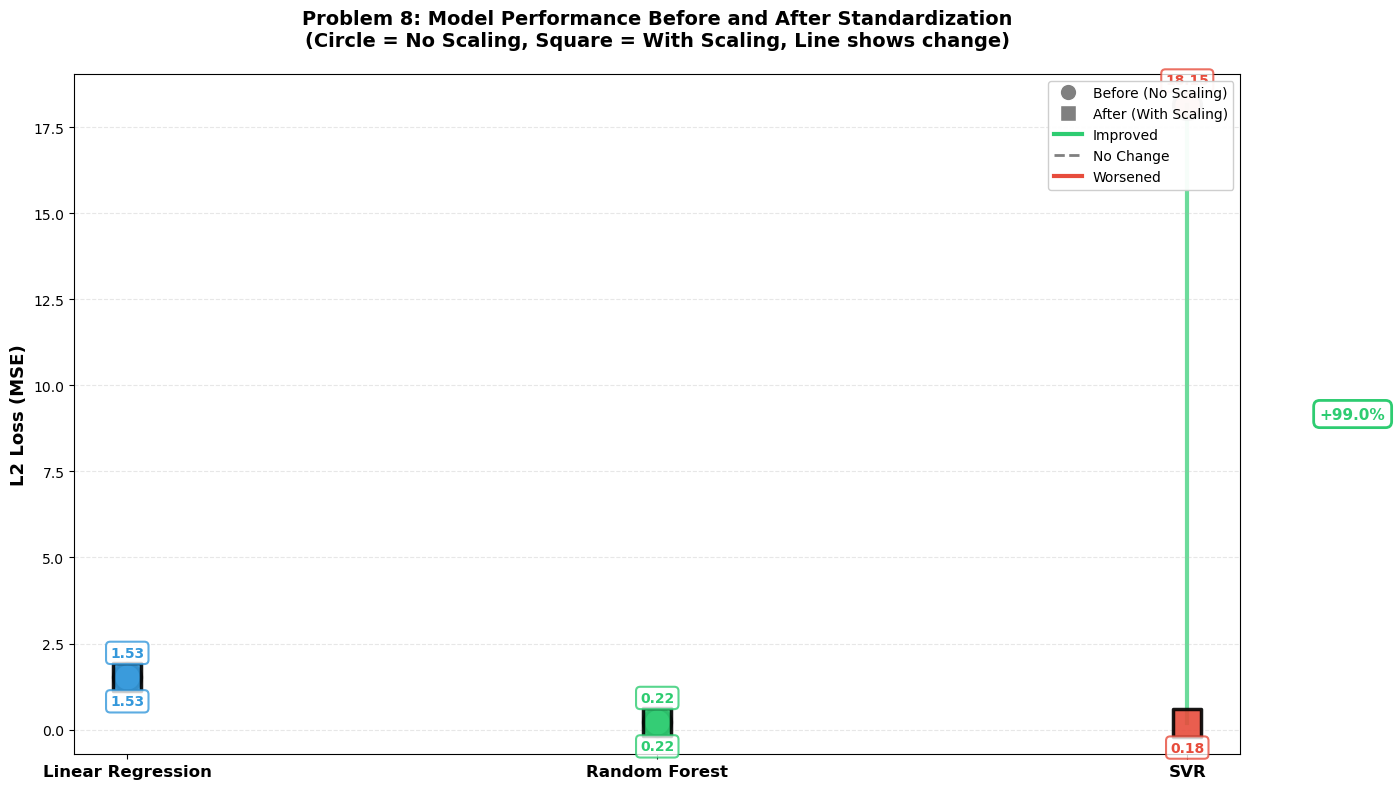

In [21]:
fig, ax = plt.subplots(figsize=(14, 8))

# ============================================================================
# Connected Scatter Plot: Before and After Standardization
# ============================================================================
# This visualization connects each model's performance before and after
# standardization with lines, making the direction and magnitude of change
# immediately visible. The line color and thickness indicate the degree
# of improvement or worsening.
# ============================================================================
models = ['Linear Regression', 'Random Forest', 'SVR']
no_scaling = [l2_loss_lr, l2_loss_rf, l2_loss_svr]
with_scaling = [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled]

x_pos = np.arange(len(models))
colors = ['#3498db', '#2ecc71', '#e74c3c']

# Plot points
for i, (no, scaled, color) in enumerate(zip(no_scaling, with_scaling, colors)):
    # Before point
    ax.scatter(i, no, s=400, color=color, alpha=0.7, edgecolors='black', 
              linewidth=2.5, marker='o', label=models[i] if i == 0 else '', zorder=3)
    # After point
    ax.scatter(i, scaled, s=400, color=color, alpha=0.9, edgecolors='black', 
              linewidth=2.5, marker='s', zorder=3)
    
    # Connect with line - color and style based on improvement
    diff = no - scaled
    if abs(diff) < 0.01:
        line_color = 'gray'
        line_style = '--'
        line_width = 2
    elif diff > 0:  # Improved
        line_color = '#2ecc71'
        line_style = '-'
        line_width = 3
    else:  # Worsened
        line_color = '#e74c3c'
        line_style = '-'
        line_width = 3
    
    ax.plot([i, i], [no, scaled], color=line_color, linestyle=line_style, 
           linewidth=line_width, alpha=0.7, zorder=1)
    
    # Add value labels
    ax.text(i, no + 0.5, f'{no:.2f}', ha='center', va='bottom', 
           fontsize=10, fontweight='bold', color=color,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, 
                    edgecolor=color, linewidth=1.5))
    ax.text(i, scaled - 0.5, f'{scaled:.2f}', ha='center', va='top', 
           fontsize=10, fontweight='bold', color=color,
           bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, 
                    edgecolor=color, linewidth=1.5))
    
    # Add improvement percentage
    if abs(diff) > 0.01:
        improvement_pct = (diff / no) * 100
        mid_y = (no + scaled) / 2
        ax.text(i + 0.25, mid_y, f'{improvement_pct:+.1f}%', 
               ha='left', va='center', fontsize=11, fontweight='bold',
               color=line_color,
               bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                        edgecolor=line_color, linewidth=2))

ax.set_xticks(x_pos)
ax.set_xticklabels(models, fontsize=12, fontweight='bold')
ax.set_ylabel('L2 Loss (MSE)', fontsize=13, fontweight='bold')
ax.set_title('Problem 8: Model Performance Before and After Standardization\n(Circle = No Scaling, Square = With Scaling, Line shows change)', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', 
           markersize=12, label='Before (No Scaling)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', 
           markersize=12, label='After (With Scaling)'),
    Line2D([0], [0], color='#2ecc71', linewidth=3, label='Improved'),
    Line2D([0], [0], color='gray', linewidth=2, linestyle='--', label='No Change'),
    Line2D([0], [0], color='#e74c3c', linewidth=3, label='Worsened')
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

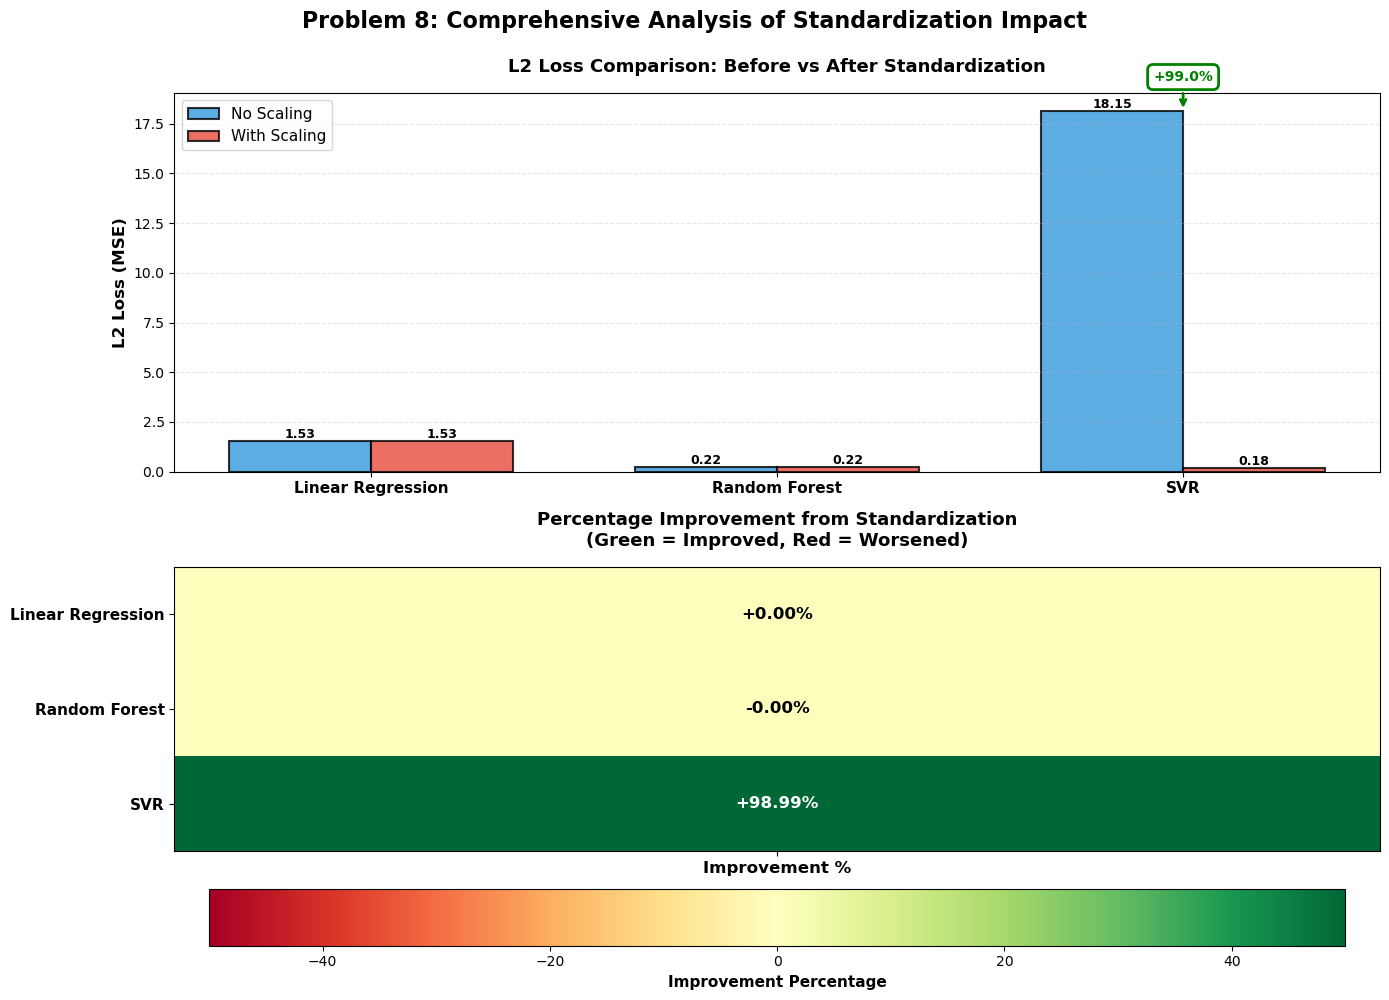

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ============================================================================
# Top Plot: Bar Chart with Detailed Annotations
# ============================================================================
models = ['Linear Regression', 'Random Forest', 'SVR']
no_scaling = [l2_loss_lr, l2_loss_rf, l2_loss_svr]
with_scaling = [l2_loss_lr_scaled, l2_loss_rf_scaled, l2_loss_svr_scaled]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, no_scaling, width, 
               label='No Scaling', color='#3498db', alpha=0.8, 
               edgecolor='black', linewidth=1.5)
bars2 = ax1.bar(x + width/2, with_scaling, width, 
               label='With Scaling', color='#e74c3c', alpha=0.8, 
               edgecolor='black', linewidth=1.5)

ax1.set_ylabel('L2 Loss (MSE)', fontsize=12, fontweight='bold')
ax1.set_title('L2 Loss Comparison: Before vs After Standardization', 
             fontsize=13, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11, fontweight='bold')
ax1.legend(fontsize=11, loc='upper left')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels and improvement indicators
for i, (no, scaled) in enumerate(zip(no_scaling, with_scaling)):
    ax1.text(i - width/2, no, f'{no:.2f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')
    ax1.text(i + width/2, scaled, f'{scaled:.2f}', ha='center', va='bottom', 
            fontsize=9, fontweight='bold')
    
    diff = no - scaled
    improvement_pct = (diff / no) * 100 if no > 0 else 0
    
    if abs(improvement_pct) > 0.01:
        color = 'green' if improvement_pct > 0 else 'red'
        ax1.annotate(f'{improvement_pct:+.1f}%', 
                    xy=(i, max(no, scaled)), 
                    xytext=(i, max(no, scaled) + 1.5),
                    ha='center', fontsize=10, fontweight='bold', color=color,
                    arrowprops=dict(arrowstyle='->', color=color, lw=2),
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                             edgecolor=color, linewidth=2))

# ============================================================================
# Bottom Plot: Heatmap of Performance Change
# ============================================================================
# This heatmap visualizes the relative change, making it easy to identify
# which models benefit most from standardization at a glance.
# ============================================================================
improvements_pct = [(no - scaled) / no * 100 for no, scaled in zip(no_scaling, with_scaling)]

# Create a matrix for heatmap
heatmap_data = np.array([improvements_pct]).T
im = ax2.imshow(heatmap_data, cmap='RdYlGn', aspect='auto', 
               vmin=-50, vmax=50)  # Adjust vmin/vmax based on your data

ax2.set_xticks([0])
ax2.set_xticklabels(['Improvement %'], fontsize=12, fontweight='bold')
ax2.set_yticks(range(len(models)))
ax2.set_yticklabels(models, fontsize=11, fontweight='bold')
ax2.set_title('Percentage Improvement from Standardization\n(Green = Improved, Red = Worsened)', 
             fontsize=13, fontweight='bold', pad=15)

# Add text annotations
for i, imp in enumerate(improvements_pct):
    text_color = 'white' if abs(imp) > 5 else 'black'
    ax2.text(0, i, f'{imp:+.2f}%', ha='center', va='center', 
            color=text_color, fontsize=12, fontweight='bold')

cbar = plt.colorbar(im, ax=ax2, orientation='horizontal', pad=0.1)
cbar.set_label('Improvement Percentage', fontsize=11, fontweight='bold')

plt.suptitle('Problem 8: Comprehensive Analysis of Standardization Impact', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()